In [25]:
import sys; sys.path.append("..")
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import sem, t
import matplotlib.pyplot as plt
import numpy as np
import shap
import os
# import featurizers
from src.featurizers import SubstituentPropertyFeaturizer, SymmetryAwareFeaturizer, StructurePropertyFeaturizer, ComboFeaturizer, FunctionFeaturizer
from src.sqlmodels import Substituent, SubstituentProperty, StructureSubstituents
from src import utils, config
from scripts.train_models import TARGET_FEATURIZER, MACROCYCLE_FEATURIZERS, AXIAL_FEATURIZERS, METAL_FEATURIZERS
utils.define_pallet()
# connect to database
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
engine = create_engine("sqlite:///{}".format("../main.db"))
session = sessionmaker(bind=engine)()
all_sids = [x[0] for x in session.execute(text("SELECT id FROM structures")).all()]
import matplotlib as mpl
c = "#F2F2F2"
mpl.rcParams["figure.facecolor"] = c
mpl.rcParams["axes.facecolor"] = c
mpl.rcParams["savefig.facecolor"] = c
plt.rcParams['font.size'] = 16
utils.define_pallet()

In [7]:
df = utils.read_raw_performance_results("../models")

In [8]:
df

,train_rmse,train_mae,train_mare,train_r_squared,test_rmse,test_mae,test_mare,test_r_squared,avg_val_rmse,avg_val_mae,avg_val_mare,avg_val_r_squared,metal,macro,axial,target,bootstrap_id
0,0.086226,0.056182,0.020484,0.899959,0.173652,0.114875,0.040200,0.331956,0.221047,0.142707,0.052825,0.198270,base,hydrogen_loewdin,homo_lumo,gap,4
1,0.079794,0.052129,0.018897,0.910144,0.235614,0.154513,0.055951,0.104723,0.197196,0.131150,0.047929,0.310401,base,hydrogen_loewdin,homo_lumo,gap,7
2,0.082769,0.052782,0.019370,0.910577,0.161279,0.115085,0.039026,0.313686,0.200320,0.134243,0.048928,0.307827,base,hydrogen_loewdin,homo_lumo,gap,9
3,0.081360,0.053402,0.019370,0.909948,0.251548,0.141701,0.055508,0.090608,0.205829,0.134387,0.049416,0.262660,base,hydrogen_loewdin,homo_lumo,gap,5
4,0.086616,0.055894,0.020495,0.902692,0.167390,0.123842,0.039746,0.353756,0.207922,0.140903,0.051674,0.280680,base,hydrogen_loewdin,homo_lumo,gap,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,0.086045,0.054427,0.019747,0.882753,0.187804,0.103309,0.038325,0.313886,0.209736,0.131616,0.048472,0.314300,base,hydrogen_mulliken,connected_atom_mulliken,gap,0
512,0.076711,0.050829,0.017904,0.894240,0.288988,0.137424,0.064959,0.382686,0.175067,0.116816,0.041604,0.385265,base,hydrogen_mulliken,connected_atom_mulliken,gap,2
513,0.086709,0.054885,0.019881,0.873716,0.217841,0.120654,0.047612,0.429342,0.207484,0.128667,0.047296,0.290794,base,hydrogen_mulliken,connected_atom_mulliken,gap,1
514,0.085578,0.052051,0.019063,0.884268,0.182718,0.129544,0.045045,0.385590,0.211267,0.129527,0.047920,0.294036,base,hydrogen_mulliken,connected_atom_mulliken,gap,6


In [9]:
# Group by target, macro, and axial
grouped = df.groupby(["target", "macro", "axial"])["avg_val_mae"]

# Calculate mean and 95% CI
summary = grouped.agg(['mean', 'count', 'std']).reset_index()
summary["sem"] = summary["std"] / summary["count"]**0.5
confidence = 0.95
summary["ci95"] = summary["sem"] * t.ppf((1 + confidence) / 2., summary["count"] - 1)

# Final dataframe with required columns
avg_mae_ci_df = summary[["target", "macro", "axial", "mean", "ci95"]].rename(
    columns={"mean": "val_mae_mean", "ci95": "val_mae_ci"}
)

Text(0, 0.5, 'Validation MAE (eV)')

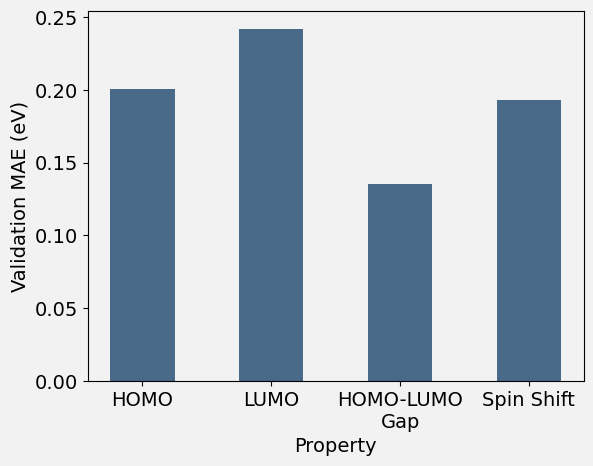

In [10]:
ajr = avg_mae_ci_df[~avg_mae_ci_df["macro"].str.contains("raw")][["target", "val_mae_mean"]].groupby("target").mean()
plt.bar(range(len(ajr)), ajr["val_mae_mean"], width=0.5)
plt.xticks(range(len(ajr)), ["HOMO", "LUMO", "HOMO-LUMO\nGap", "Spin Shift"])
plt.xlabel("Property")
plt.ylabel("Validation MAE (eV)")

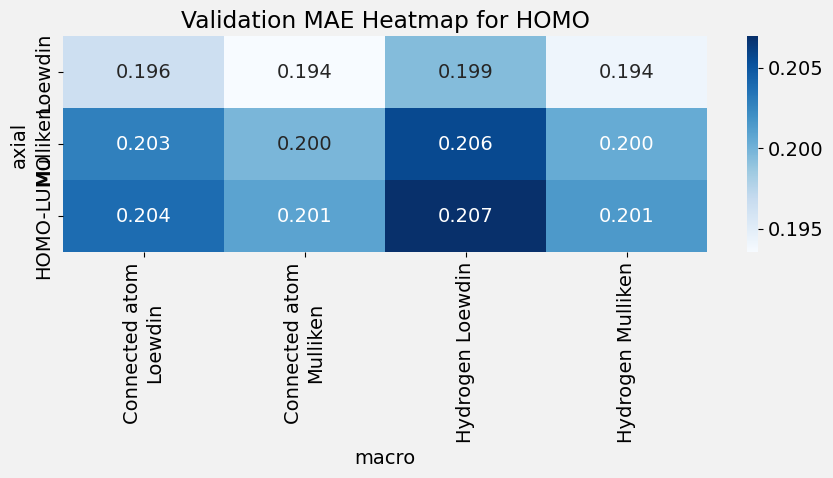

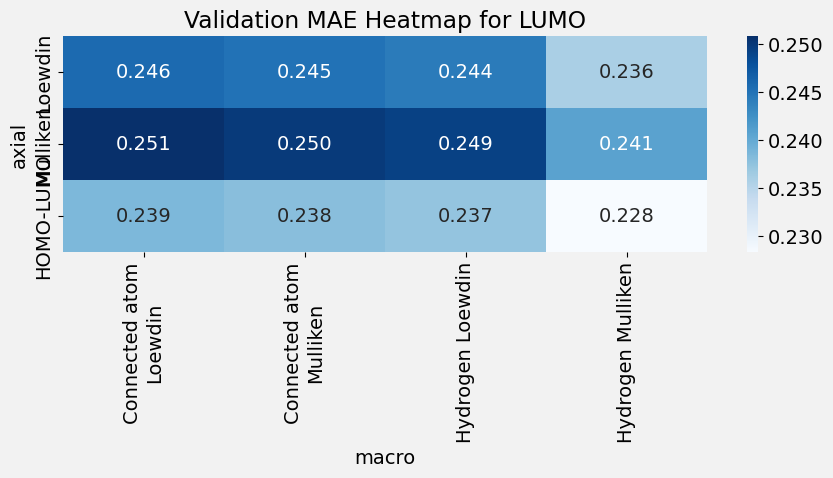

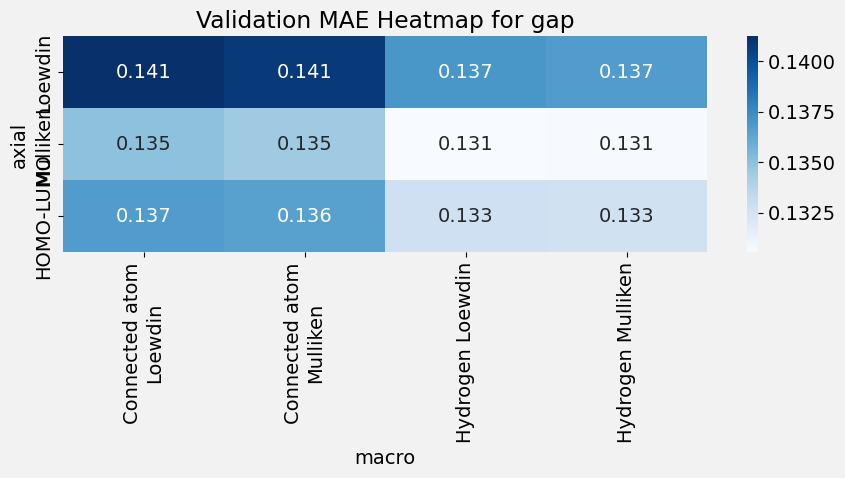

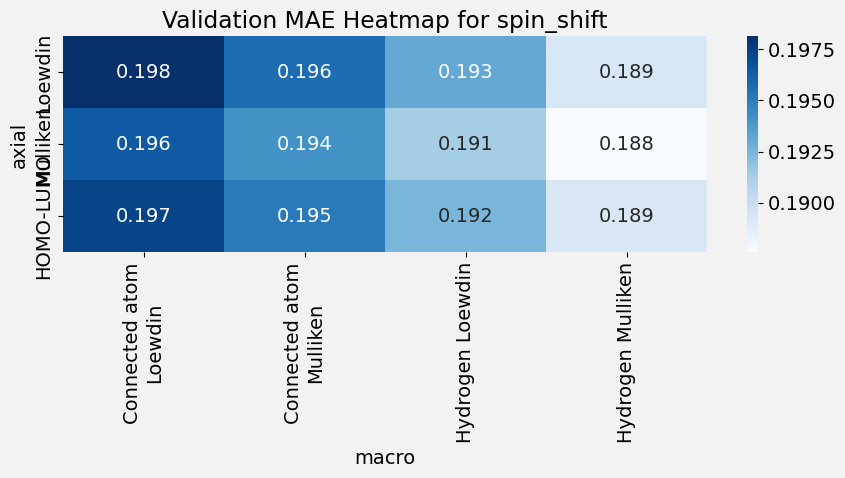

In [31]:
import seaborn as sns
xdisplay_dict = {
    "connected_atom_loewdin": "Connected atom\nLoewdin",
    "connected_atom_mulliken": "Connected atom\nMulliken",
    "hydrogen_loewdin": "Hydrogen Loewdin",
    "hydrogen_mulliken": "Hydrogen Mulliken",
    "homo_lumo": "HOMO-LUMO"
}

ydisplay_dict = {
    "connected_atom_loewdin": "Loewdin",
    "connected_atom_mulliken": "Mulliken",
    "homo_lumo": "HOMO-LUMO"
}


targets = avg_mae_ci_df["target"].unique()
for target in targets:
    pivot = avg_mae_ci_df[(avg_mae_ci_df["target"] == target) & ~avg_mae_ci_df["macro"].str.contains("raw")].pivot(
        index="axial", columns="macro", values="val_mae_mean"
    )
    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", xticklabels=[xdisplay_dict[x] for x in pivot.columns], yticklabels=[ydisplay_dict[x] for x in pivot.index])
    plt.title(f"Validation MAE Heatmap for {target}")
    plt.xlabel("macro")
    plt.ylabel("axial")
    plt.tight_layout()
    plt.show()

In [15]:
sids = utils.sids_by_type(session)
target_properties_df = TARGET_FEATURIZER.featurize(session, sids)

In [16]:
target_properties_df

,HOMO,LUMO,gap,spin_shift
ADIQAI,-5.635,-2.6153,3.0197,0.545094
AKOTUQ,-5.2579,-2.3274,2.9305,0.56074
ALITEU,None,None,None,None
ANUYOY,None,None,None,None
APANUC,-5.1386,-2.2377,2.9009,1.590224
...,...,...,...,...
ZONQOI,None,None,None,None
ZONXEF,None,None,None,None
ZOXQUA,-5.7245,-2.6171,3.1074,1.806496
ZUTQEK,None,None,None,None


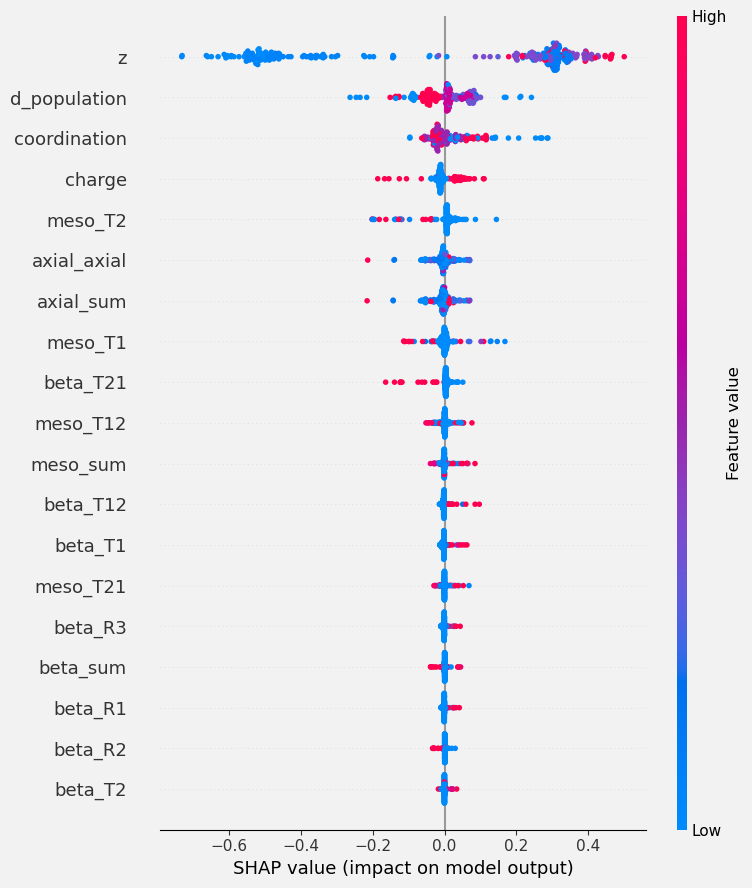

In [33]:
def read_shap(macro, axial, target) -> pd.DataFrame:
    model_dir = os.path.join("../models", f"metal=base_macro={macro}_axial={axial}_target={target}")
    ajr = []
    for bootstrap in os.listdir(model_dir):
        x = pd.read_csv(os.path.join(model_dir, bootstrap, "shap.csv"), index_col=0)
        x["bootstrap"] = int(bootstrap)
        ajr.append(x)
    return pd.concat(ajr)

target = "spin_shift"
macro = "hydrogen_mulliken"
axial = "connected_atom_mulliken"

shap_df = read_shap(macro, axial, target)
# shap_df = read_shap("connected_atom_mulliken", "homo_lumo", "LUMO")
mean_shap = shap_df.drop(columns="bootstrap").groupby(by=shap_df.index).mean()

feat = METAL_FEATURIZERS["base"] + MACROCYCLE_FEATURIZERS[macro] + AXIAL_FEATURIZERS[axial]

xtrain = feat.featurize(session, mean_shap.index)

shap.summary_plot(mean_shap.values, xtrain.values, feature_names=xtrain.columns)


# plt.figure(figsize=(14, 6))
# mean_abs_shap = mean_shap.abs()
# mean_abs_shap_sum = mean_abs_shap.sum(axis=1)
# mean_abs_shap = mean_abs_shap.div(mean_abs_shap_sum, axis=0)
# # mean_abs_shap["beta"] = mean_abs_shap[[c for c in mean_abs_shap.columns if "beta" in c]].sum(axis=1)
# # mean_abs_shap["meso"] = mean_abs_shap[[c for c in mean_abs_shap.columns if "meso" in c]].sum(axis=1)
# # mean_abs_shap = mean_abs_shap[[c for c in mean_abs_shap.columns if "beta_" not in c and "meso_" not in c]]
# mean_abs_shap = mean_abs_shap.mean(axis=0).sort_values(ascending=False)

# sns.barplot(x=mean_abs_shap.index, y=mean_abs_shap.values, color="skyblue")
# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Mean |SHAP value|")
# plt.title("Mean absolute SHAP value for each feature")
# plt.tight_layout()
# plt.show()

In [ ]:
properties = df["target"].unique()
fig, axes = plt.subplots(len(properties), 2, figsize=(10, 4 * len(properties)))

for i, prop in enumerate(properties):
    subset = df[df["target"] == prop]
    axes[i, 0].hist(subset["avg_val_mae"], bins=20, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f"{prop} - avg_val_mae")
    axes[i, 0].set_xlabel("avg_val_mae")
    axes[i, 0].set_ylabel("Count")

    axes[i, 1].hist(subset["test_mae"], bins=20, color='salmon', edgecolor='black')
    axes[i, 1].set_title(f"{prop} - test_mae")
    axes[i, 1].set_xlabel("test_mae")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Play with features and training

In [208]:
def orca_properties_df(session, sids, source: str):
    # reading the data from SQL
    props = ["final_energy", "HOMO-0_energy", "LUMO+0_energy"]
    units = [None for _ in range(len(props))]
    feat = StructurePropertyFeaturizer(props, units, navalue=None, property_source=source)
    df = feat.featurize(session, sids)
    df = df.dropna()
    return df

singlet = orca_properties_df(session, all_sids, "parser/S1")
triplet = orca_properties_df(session, all_sids, "parser/S3")
quintet = orca_properties_df(session, all_sids, "parser/S5")

# Join singlet, triplet, and quintet energies into a single DataFrame
energies = pd.DataFrame(index=all_sids)
energies["singlet_energy"] = singlet["final_energy"]
energies["triplet_energy"] = triplet["final_energy"]
energies["quintet_energy"] = quintet["final_energy"]

# Drop rows with missing energies
energies = energies.dropna()

# Find the spin state with the lowest energy for each structure
energies["lowest_spin"] = energies[["singlet_energy", "triplet_energy", "quintet_energy"]].idxmin(axis=1)
# Use DataFrame.lookup is deprecated, use DataFrame.to_numpy with column index instead
energies["lowest_energy"] = energies.apply(lambda row: row[row["lowest_spin"]], axis=1)

# Map spin state to the corresponding HOMO and LUMO energies
def get_homo_lumo(row):
    spin = row["lowest_spin"].split("_")[0]
    if spin == "singlet":
        df_ref = singlet
    elif spin == "triplet":
        df_ref = triplet
    else:
        df_ref = quintet
    return pd.Series({
        "HOMO_energy": df_ref.at[row.name, "HOMO-0_energy"],
        "LUMO_energy": df_ref.at[row.name, "LUMO+0_energy"]
    })

energies[["HOMO_energy", "LUMO_energy"]] = energies.apply(get_homo_lumo, axis=1)

energies["HOMO-LUMO_gap"] = energies["LUMO_energy"] - energies["HOMO_energy"]

# Add one-hot encoded columns for the lowest spin state (singlet=[1,0,0], triplet=[0,1,0], quintet=[0,0,1])
spin_map = {"singlet_energy": [1, 0, 0], "triplet_energy": [0, 1, 0], "quintet_energy": [0, 0, 1]}
energies[["is_singlet", "is_triplet", "is_quintet"]] = energies["lowest_spin"].map(spin_map).apply(pd.Series)

# Calculate the energy difference between the lowest and second lowest spin states
def spin_shift(row):
    energies_row = row[["singlet_energy", "triplet_energy", "quintet_energy"]].values
    sorted_energies = np.sort(energies_row)
    return (sorted_energies[1] - sorted_energies[0]) * 27.2114

energies["spin_shift_energy"] = energies.apply(spin_shift, axis=1)
energies

,singlet_energy,triplet_energy,quintet_energy,lowest_spin,lowest_energy,HOMO_energy,LUMO_energy,HOMO-LUMO_gap,is_singlet,is_triplet,is_quintet,spin_shift_energy
ADIQAI,-4118.599836,-4118.614815,-4118.634847,quintet_energy,-4118.634847,-5.6350,-2.6153,3.0197,0,0,1,0.545094
AKOTUQ,-4852.775466,-4852.754860,-4852.693657,singlet_energy,-4852.775466,-5.2579,-2.3274,2.9305,1,0,0,0.560740
APANUC,-5632.361713,-5632.303273,-5632.234835,singlet_energy,-5632.361713,-5.1386,-2.2377,2.9009,1,0,0,1.590224
ARODOC,-2485.499488,-2485.428626,-2485.356490,singlet_energy,-2485.499488,-5.4578,-2.2415,3.2163,1,0,0,1.928250
ASIPIB,-4392.260591,-4392.332325,-4392.271117,triplet_energy,-4392.332325,-5.8162,-2.7849,3.0313,0,1,0,1.665559
...,...,...,...,...,...,...,...,...,...,...,...,...
ZITNIZ,-4085.376097,-4085.312164,-4085.244119,singlet_energy,-4085.376097,-5.6714,-2.6169,3.0545,1,0,0,1.739704
ZOHQOE,-3265.421061,-3265.401200,-3265.332443,singlet_energy,-3265.421061,-5.4672,-2.2273,3.2399,1,0,0,0.540436
ZOHQUK,-3724.888487,-3724.866470,-3724.800703,singlet_energy,-3724.888487,-5.5026,-2.4129,3.0897,1,0,0,0.599121
ZOXQUA,-6801.109174,-6801.042787,-6800.971677,singlet_energy,-6801.109174,-5.7245,-2.6171,3.1074,1,0,0,1.806496


In [217]:
energies = energies[energies["spin_shift_energy"] >= 0.5]

In [238]:
mesos = [f"meso{i + 1}" for i in range(4)]
betas = [f"beta{i + 1}" for i in range(8)]
axials = ["axial1", "axial2"]

def featurize_positions(positions, property_name, property_source=None, symmetries="macrocycle", position_name="meso") -> SymmetryAwareFeaturizer:
    navalue = 0 if position_name == "axial" else None
    subsfeat = SubstituentPropertyFeaturizer(property_name, positions, navalue=navalue, source=property_source)
    feat = SymmetryAwareFeaturizer(subsfeat, symmetries, custom_funcs={"total": lambda df: df[[c for c in df.columns if position_name in c]].sum(axis=1)})
    feat.feature_names = feat.feature_names[:-2] + [position_name + "_total", position_name + "_assymetry_total"]
    return feat

def featurize_metal(session, sid: int):
    """Get the VDW radius of the metal center"""
    # Get the substituent id for the metal position
    metal_sub = session.query(StructureSubstituents.substituent).filter(
        StructureSubstituents.structure == sid,
        StructureSubstituents.position == "metal"
    ).scalar()
    # Get the SMILES string for the metal substituent
    metal_smiles = session.query(Substituent.smiles).filter(Substituent.id == metal_sub).scalar()
    metal = utils.mol_from_smiles(metal_smiles).GetAtom(1)
    metal_charge = session.query(SubstituentProperty.value).filter(SubstituentProperty.structure == sid).filter(SubstituentProperty.property == "charge").first()[0]
    d_population = session.query(SubstituentProperty.value).filter(SubstituentProperty.structure == sid).filter(SubstituentProperty.property == "d_population").first()[0]
    return [metal.GetAtomicNum(), metal_charge, d_population]


In [261]:
mesos_df = featurize_positions(mesos, "hydrogen_loewdin", property_source="orca_substituent_property/with_h", symmetries="macrocycle", position_name="meso").featurize(session, all_sids) / 4
betas_df = featurize_positions(betas, "hydrogen_loewdin", property_source="orca_substituent_property/with_h", symmetries="macrocycle", position_name="beta").featurize(session, all_sids) / 8
axials_df = featurize_positions(axials, "connected_atom_loewdin", property_source="orca_substituent_property/no_h", symmetries="axial", position_name="axial").featurize(session, all_sids) / 2
metal_df = FunctionFeaturizer(["metal_z", "metal_charge", "d_population"], featurize_metal, navalue=None).featurize(session, all_sids)

features_df = mesos_df[[c for c in mesos_df.columns if "meso" not in c]] + betas_df[[c for c in betas_df.columns if "beta" not in c]]
features_df["total_meso"] = mesos_df["meso_total"]
features_df["total_meso_assymetry"] = mesos_df["meso_assymetry_total"]
features_df["total_beta"] = betas_df["beta_total"]
features_df["total_beta_assymetry"] = betas_df["beta_assymetry_total"]
features_df["total_axial"] = axials_df["axial_total"]
features_df["total_axial_assymetry"] = axials_df["axial_assymetry_total"]
features_df[[c for c in metal_df.columns]] = metal_df.values
features_df

,T1,T2,T12,T21,R1,R2,R3,total_meso,total_meso_assymetry,total_beta,total_beta_assymetry,total_axial,total_axial_assymetry,metal_z,metal_charge,d_population
ADIQAI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.167544,0.000000,0.000000,0.000000,-0.295683,0.349713,25.0,3.0,4.0
AKOTUQ,0.000000,0.008590,0.008590,0.008590,0.008590,0.008590,0.008590,0.139142,0.004302,0.031371,0.047238,0.000000,0.000000,28.0,2.0,8.0
ALITEU,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.129981,0.000000,0.000000,0.000000,0.359135,0.794747,44.0,2.0,6.0
ANUYOY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.131203,0.000000,0.000000,0.000000,-0.144447,0.083460,45.0,3.0,6.0
APANUC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.134147,0.000000,0.000000,0.000000,-0.155313,0.096489,30.0,2.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZONQOI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.167544,0.000000,0.000000,0.000000,0.168427,0.113471,27.0,3.0,6.0
ZONXEF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.167544,0.000000,0.000000,0.000000,0.044514,0.000000,26.0,2.0,6.0
ZOXQUA,0.002800,0.002800,0.000000,0.005601,0.002800,0.005601,0.002800,0.168623,0.022404,0.000000,0.000000,0.000000,0.000000,46.0,2.0,8.0
ZUTQEK,0.000054,0.007344,0.007344,0.007344,0.007290,0.007290,0.007290,0.030187,0.043741,0.125746,0.000215,-0.062792,0.015771,30.0,2.0,10.0


In [262]:
# subsfeat = ComboFeaturizer([
#     SubstituentPropertyFeaturizer("hydrogen_mulliken", mesos + betas, navalue=None, source="orca_substituent_property/with_h"), 
#     SubstituentPropertyFeaturizer("connected_atom_mulliken", axials, navalue=-1, source="orca_substituent_property/no_h"),
#     FunctionFeaturizer(["metal_z", "metal_charge", "d_population"], featurize_metal, navalue=None)
#     ])
# features_df = subsfeat.featurize(session, all_sids)

In [263]:
len(features_df.dropna())

410

In [264]:
df = features_df.copy()
df["diag"] = df["T1"] + df["T2"]
df["line"] = df["T12"] + df["T21"]
df["rot"] = df["R1"] + df["R2"] + df["R3"]
cols = ["diag", "line", "rot"]
df = df[cols + [c for c in df.columns if not "T" in c and not "R" in c and not c in cols]]
df.corr()

,diag,line,rot,total_meso,total_meso_assymetry,total_beta,total_beta_assymetry,total_axial,total_axial_assymetry,metal_z,metal_charge,d_population
diag,1.000000,0.309382,0.831951,0.033214,0.248928,0.206469,0.912804,0.115162,-0.027923,-0.113862,-0.110991,0.183618
line,0.309382,1.000000,0.781456,-0.249550,0.923970,0.084740,0.127891,0.253243,-0.147113,-0.144302,-0.252511,0.232310
rot,0.831951,0.781456,1.000000,-0.127092,0.711912,0.179874,0.658110,0.221250,-0.101829,-0.155689,-0.218555,0.256169
total_meso,0.033214,-0.249550,-0.127092,1.000000,-0.260727,-0.350431,0.084446,-0.015992,0.015775,-0.016614,-0.012897,0.136495
total_meso_assymetry,0.248928,0.923970,0.711912,-0.260727,1.000000,0.058685,-0.059371,0.235751,-0.138124,-0.130640,-0.235970,0.221303
total_beta,0.206469,0.084740,0.179874,-0.350431,0.058685,1.000000,0.193943,0.038382,-0.041229,-0.063541,-0.079647,-0.053616
total_beta_assymetry,0.912804,0.127891,0.658110,0.084446,-0.059371,0.193943,1.000000,0.069407,-0.006765,-0.082316,-0.063893,0.129658
total_axial,0.115162,0.253243,0.221250,-0.015992,0.235751,0.038382,0.069407,1.000000,-0.714499,-0.152244,-0.794575,0.561812
total_axial_assymetry,-0.027923,-0.147113,-0.101829,0.015775,-0.138124,-0.041229,-0.006765,-0.714499,1.000000,0.061700,0.528859,-0.310068
metal_z,-0.113862,-0.144302,-0.155689,-0.016614,-0.130640,-0.063541,-0.082316,-0.152244,0.061700,1.000000,0.249235,-0.167587


/home/shachar/miniconda3/envs/pymatgen/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


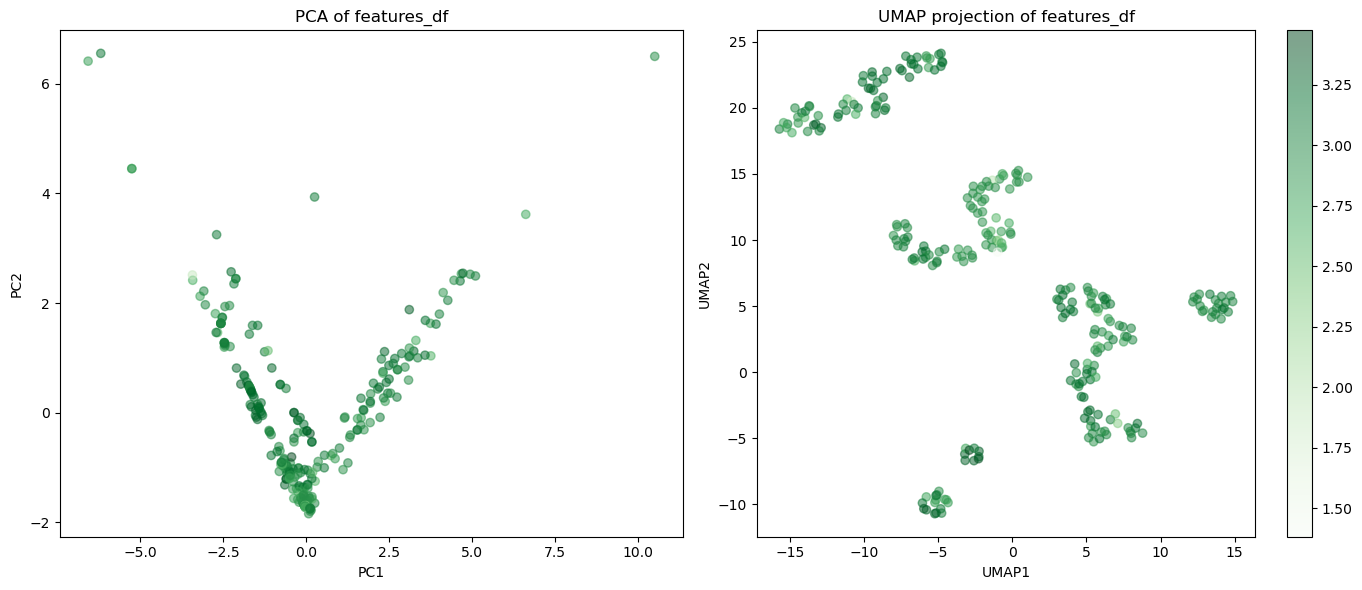

In [265]:
from sklearn.decomposition import PCA
features_clean = df.dropna()
joined_index = energies.index.intersection(features_clean.index)
features_clean = df.loc[joined_index, :]
color = energies.loc[joined_index, "HOMO-LUMO_gap"]

# Drop rows with missing values for PCA/UMAP
features_scaled = (features_clean - features_clean.mean(axis=0)) / features_clean.std(axis=0)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled.values)

# UMAP
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=1, n_components=2, random_state=42)
embedding = reducer.fit_transform(features_clean.values)

# Plot both in one figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(pca_result[:, 0], pca_result[:, 1], c=color, cmap='Greens', alpha=0.5)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA of features_df')

sc1 = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=color, cmap='Greens', alpha=0.5)
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].set_title('UMAP projection of features_df')
plt.colorbar(sc1, ax=axes[1])

plt.tight_layout()
plt.show()


N = 272 | Train MAE 0.048 | Test MAE 0.117


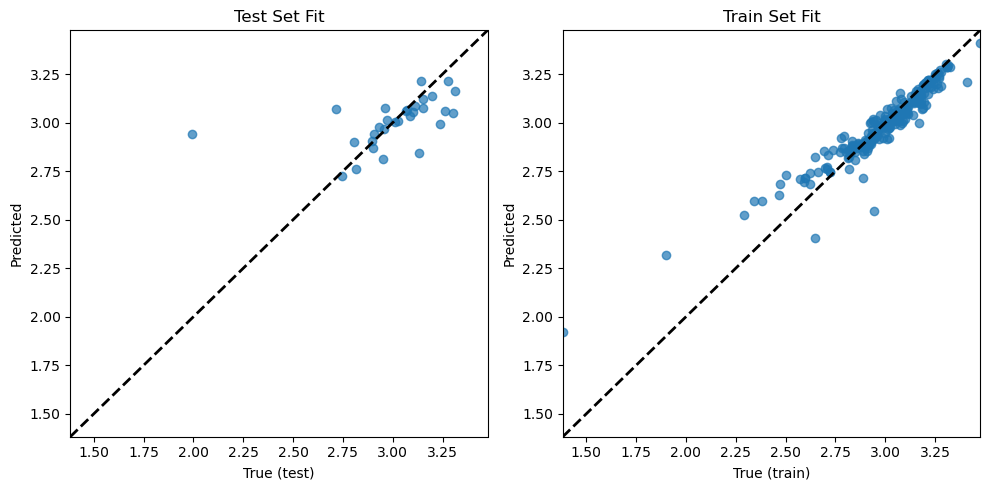

In [266]:
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge

X = df.dropna()
y = energies["HOMO-LUMO_gap"].dropna()
shared_sids = X.index.intersection(y.index)
X = X.loc[shared_sids]
y = y.loc[shared_sids]
xtrain, xtest, ytrain, ytest = train_test_split(X.values, y.values, test_size=30)
# model = KernelRidge(kernel='poly', alpha=0.00001)
model = RandomForestRegressor(n_estimators=1000)
model.fit(xtrain, ytrain)

print(f"N = {len(X)} | Train MAE {utils.calc_mae(model.predict(xtrain), ytrain):.3f} | Test MAE {utils.calc_mae(model.predict(xtest), ytest):.3f}")
# calculating metrics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Test set
axes[0].scatter(ytest, model.predict(xtest), alpha=0.7)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[0].set_xlabel("True (test)")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Test Set Fit")
axes[0].set_ylim(y.min(), y.max())
axes[0].set_xlim(y.min(), y.max())

# Train set
axes[1].scatter(ytrain, model.predict(xtrain), alpha=0.7)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
axes[1].set_xlabel("True (train)")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Train Set Fit")
axes[1].set_ylim(y.min(), y.max())
axes[1].set_xlim(y.min(), y.max())

plt.tight_layout()
plt.show()


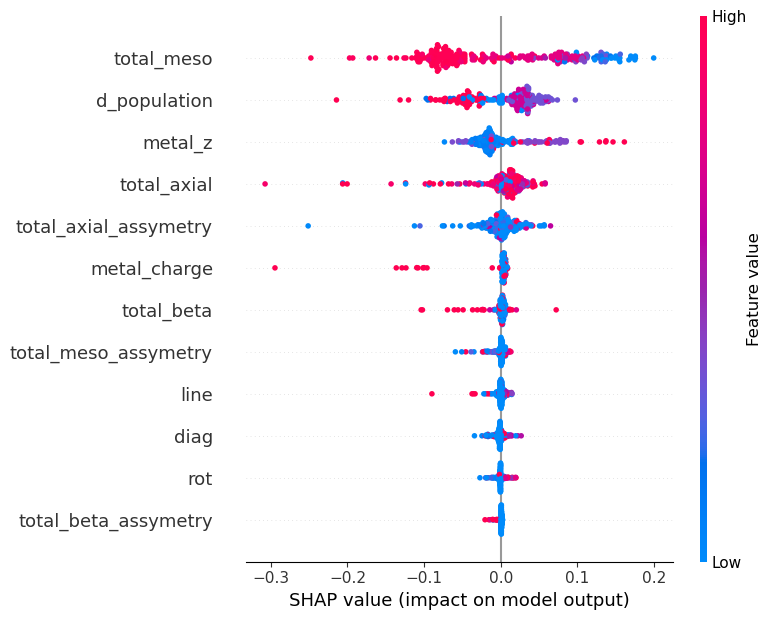

In [267]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(xtrain)

# Classical SHAP summary plot
shap.summary_plot(shap_values, xtrain, feature_names=df.columns)
